In [6]:
# Setup, ground truths
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

SIGMA = 2

# x is a Numpy array of spatial coords
def exact_phi_1(x):
    # Calculates analytical solution for f(x) = x
    # Returns an array eval at \phi_1(x) = c_1 e^{2x} + c_2 e^{-2x} + \frac{x}{4} using derived bound. condition consts
    c1 = 1.0 / (8.0 *(1.0 - np.exp(2.0)))
    c2 = 1.0 / (8.0 * (1.0 - np.exp(-2.0)))

    phi = c1 * np.exp(2.0 * x) + c2 * np.exp(-2.0 * x) + x / 4.0

    return phi




def exact_phi_2(x):
    # Calculates analytical solution for f(x) = sin(\pi x)
    # Returns an array eval at \phi_1(x) = c_1 e^{2x} + c_2 e^{-2x} + \frac{1}{\pi^2 + 4} sin(\pi x)

    c1 = -np.pi / (2*(np.pi ** 2.0 + 4.0) * (1.0 - np.exp(2.0)))
    c2 = np.pi / (2*(np.pi ** 2.0 + 4.0) * (1.0 - np.exp(-2.0)))

    phi = c1 * np.exp(2.0 * x) + c2 * np.exp(-2.0 * x) + (1.0 / (np.pi ** 2.0 + 4.0)) * np.sin(np.pi * x)

    return phi

In [7]:
# Solves the periodic BVP using the pseudospectral method using FFT
def solve_bvp_pseudospectral(N, exact_sol_func, rhs_func):
    # Step size and grid (exclude right boundary for computing)
    h = 1.0 / N
    x = np.arange(N) * h

    # Eval of rhs func on grid
    f_val = rhs_func(x)

    # build array of exact cont e-vals for operator (-d^2/dx^2 + 4)
    # np.fft.fftfreq(N) returns [0, 1, ... , N /2-1, - N/ 2, ..., -1] / N
    # mult by N gives us exact inte wave nums k
    k = np.fft.fftfreq(N) * N
    lambdas = (2.0 * np.pi * k) ** 2.0 + 4.0


    # Computing num soln using spectral factorization: u = F_N^* D^{-1} F_N f
    u = np.real(np.fft.ifft(np.fft.fft(f_val) / lambdas))

    # append per boundary point for plotting (phi(1) = phi(0))
    x_plot = np.append(x, 1.0)
    u_plot = np.append(u, u[0])

    #eval exact soln on extended grid
    exact_plot = exact_sol_func(x_plot)

    # Calculate max abs error across grid
    max_error = np.max(np.abs(exact_plot - u_plot))

    return x_plot, u_plot, exact_plot, h, max_error


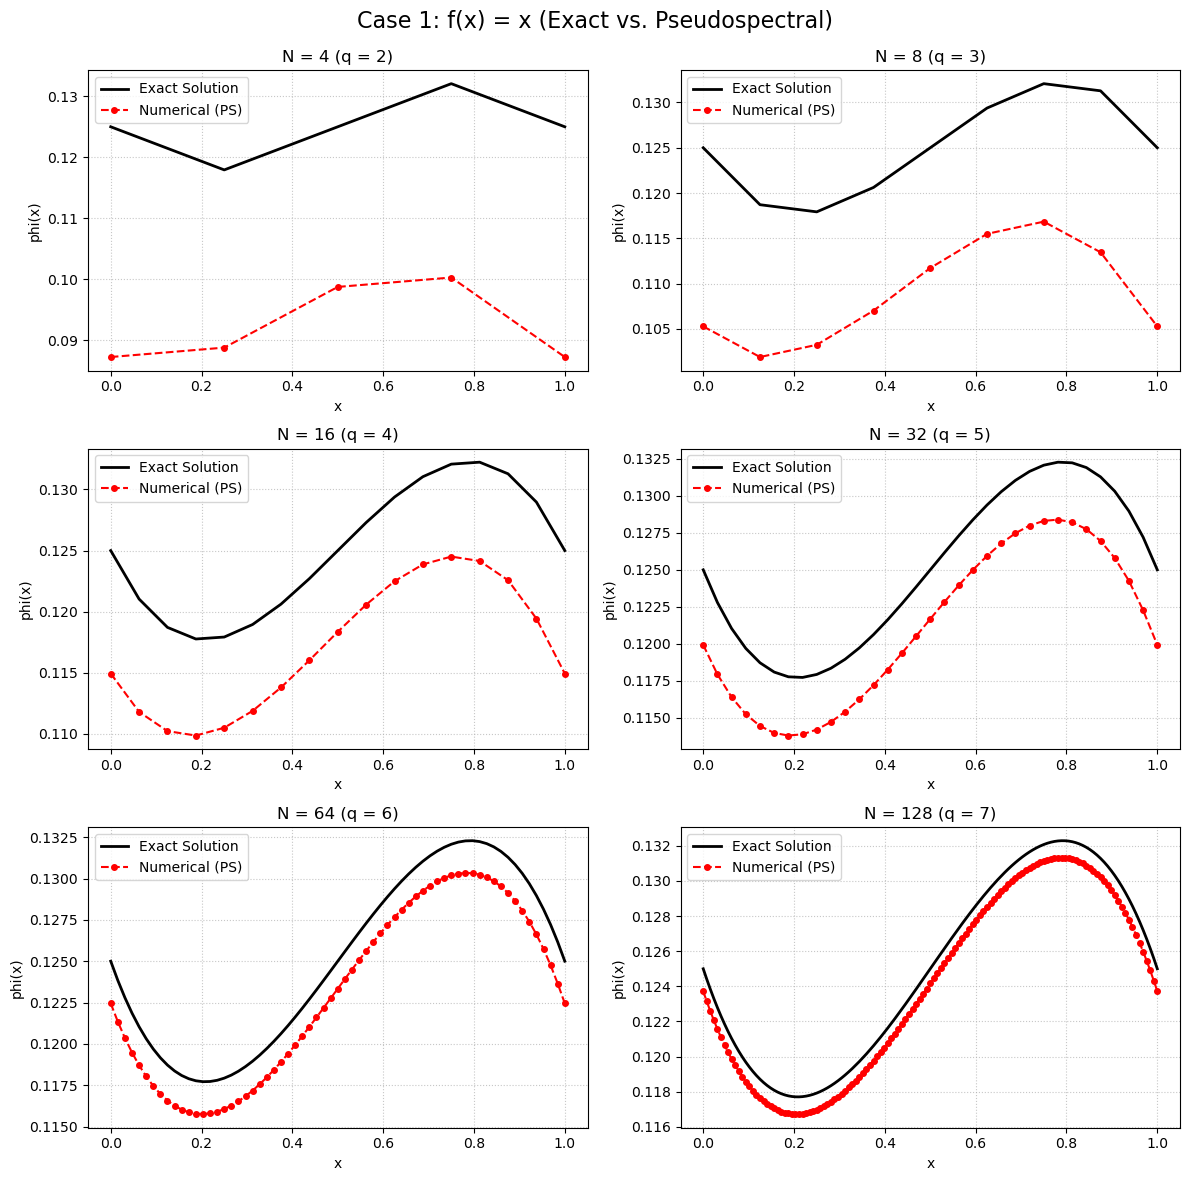

,h,max |phi_n - u_n|,max |phi_n - u_n| / h,max |phi_n - u_n| / h^2
0,0.250000,0.037772,0.151088,0.604352
1,0.125000,0.019718,0.157746,1.261966
2,0.062500,0.010060,0.160957,2.575306
3,0.031250,0.005080,0.162545,5.201454
4,0.015625,0.002552,0.163338,10.453615
5,0.007812,0.001279,0.163734,20.957902


In [8]:
# Executing/Plotting Case 1 (Pseudospec)
results_case1_ps = []

def rhs_func_1(x):
    return x

fig, axs = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle("Case 1: f(x) = x (Exact vs. Pseudospectral)", fontsize = 16)

for i, q in enumerate(range(2, 8)):
    N = 2 ** q

    # Run Pseudospect solver
    x_plot, u_plot, exact_plot, h, max_error = solve_bvp_pseudospectral(N, exact_phi_1, rhs_func_1)

    # Map loop index to 3x2 grid coordinates
    row = i // 2
    col = i % 2
    ax = axs[row, col]

    # Plot exact + num solns
    ax.plot(x_plot, exact_plot, 'k-', label="Exact Solution", linewidth=2)
    ax.plot(x_plot, u_plot, 'r--', label="Numerical (PS)", marker='o', markersize=4)
    
    # Make subplot look nice
    ax.set_title(f"N = {N} (q = {q})")
    ax.set_xlabel("x")
    ax.set_ylabel("phi(x)")
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend()

    # Get metrics for data table
    results_case1_ps.append({
        "h": h,
        "max |phi_n - u_n|": max_error,
        "max |phi_n - u_n| / h": max_error / h,
        "max |phi_n - u_n| / h^2": max_error / (h ** 2.0)
    })

# Format, show figure
plt.tight_layout()
fig.subplots_adjust(top=0.93)
plt.show()

# create, display the error table using Pandas
df_case1_ps = pd.DataFrame(results_case1_ps)
df_case1_ps

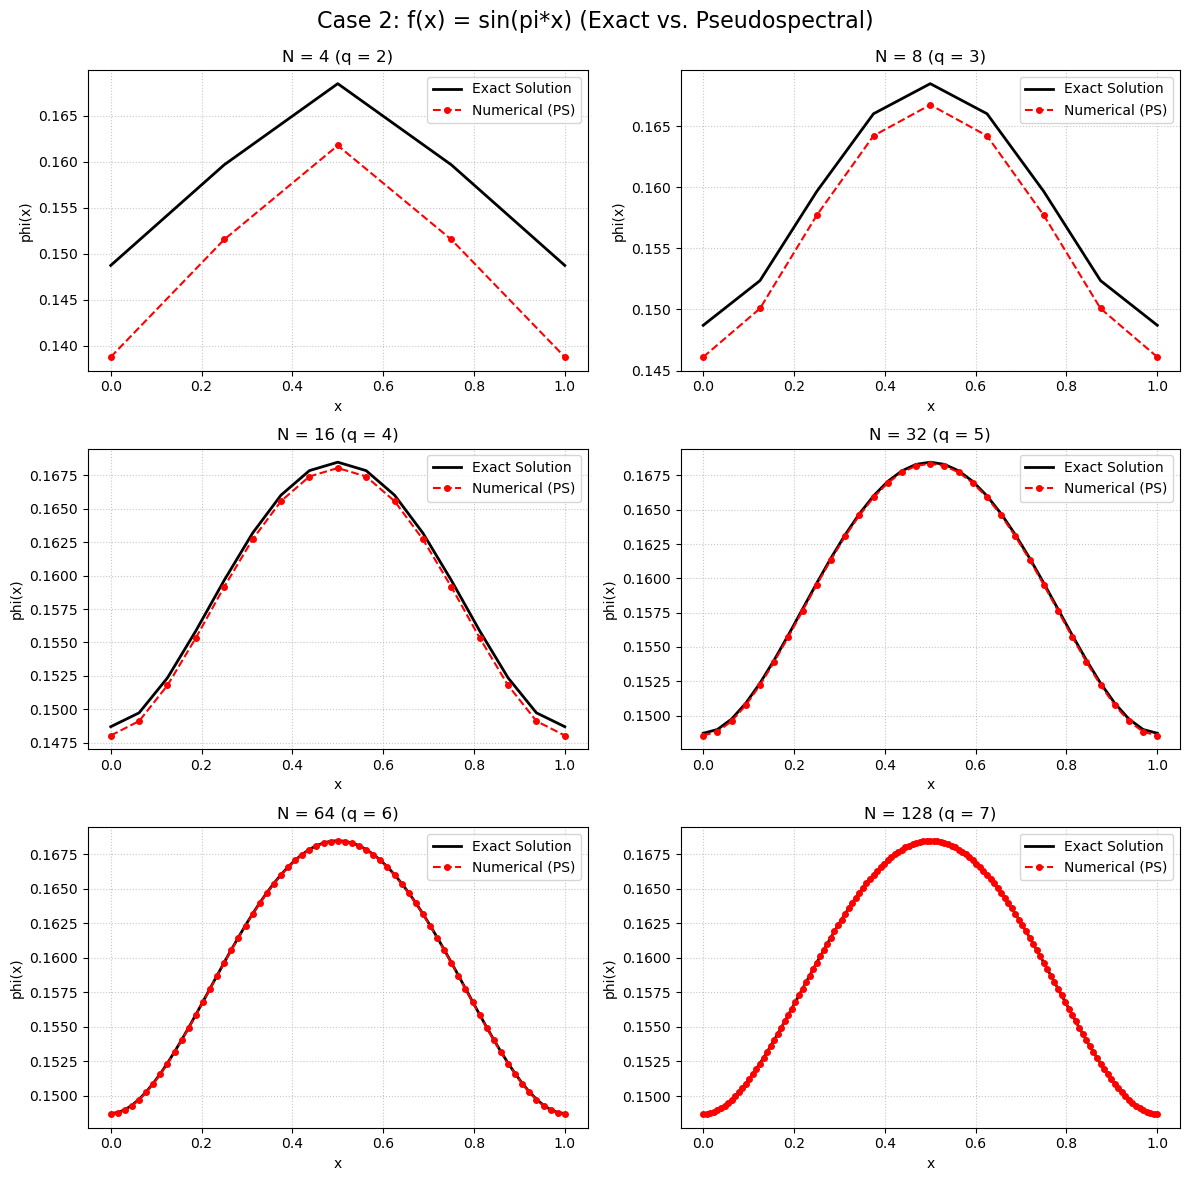

,h,max |phi_n - u_n|,max |phi_n - u_n| / h,max |phi_n - u_n| / h^2
0,0.250000,0.009958,0.039834,0.159335
1,0.125000,0.002596,0.020765,0.166122
2,0.062500,0.000660,0.010568,0.169080
3,0.031250,0.000166,0.005328,0.170491
4,0.015625,0.000042,0.002675,0.171186
5,0.007812,0.000010,0.001340,0.171531


In [9]:
# Execute/Plotting Case 2 (PS)
def rhs_func_2(x):
    return np.sin(np.pi * x)

results_case2_ps = []

fig, axs = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle("Case 2: f(x) = sin(pi*x) (Exact vs. Pseudospectral)", fontsize=16)

for i, q in enumerate(range(2, 8)):
    N = 2 ** q

    # Run Pseudospec solver
    x_plot, u_plot, exact_plot, h, max_error = solve_bvp_pseudospectral(N, exact_phi_2, rhs_func_2)

    # Map loop index to 3x2 grid coordinates
    row = i // 2
    col = i % 2
    ax = axs[row, col]

    # Plot exact + numerical solutions
    ax.plot(x_plot, exact_plot, 'k-', label="Exact Solution", linewidth=2)
    ax.plot(x_plot, u_plot, 'r--', label="Numerical (PS)", marker='o', markersize=4)

    # Make subplot look nice
    ax.set_title(f"N = {N} (q = {q})")
    ax.set_xlabel("x")
    ax.set_ylabel("phi(x)")
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend()

    # Get metrics for data table
    results_case2_ps.append({
        "h": h,
        "max |phi_n - u_n|": max_error,
        "max |phi_n - u_n| / h": max_error / h,
        "max |phi_n - u_n| / h^2": max_error / (h ** 2.0)
    })

# Format, show figure
plt.tight_layout()
fig.subplots_adjust(top=0.93)
plt.show()

# Create, display error table using Pandas
df_case2_ps = pd.DataFrame(results_case2_ps)
df_case2_ps

In the second case, the error table shows that, unlike the finite-diff method, where the error shrank quaratically and the last column stabilized to a constant, the pseudospectral error goes to near computer precision (ie 10^-14 ish). Since we are using exact cont derivs in fourier space, and since sin(pi x) is smooth and periodic, we need few grid points to get the soln perfectly. The error col goes to zero (ie confirms that convergence happens faster that O(h^2)). 

In case 1, the method fails to converge, and the max error stays "stuck" as N increases. the error / h^2 vals diverge rapudly to infinity. This is cause the pseudospec method relies on represeing the soln using a global sum of smooth and continuous sin/cos waves. our problem imposes a PBC, so f(x) = x has a discontinuosu jump at the boundary, which is impossible to represent with smooth waves. 

Unoike the finite difference method, this means that the rest of the domain has less accuracy too.